In [16]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import xarray as xr
import matplotlib.ticker as ticker


# Calcualte u dot PC1 to get EOF1_2D

In [56]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

PR = 50
base_path = f"/data92/PeterChang/Dycore_data/PR{PR}"
u_file = f"{base_path}/u/PR{PR}_500_20000day_u_6hourly.h5"

# --- Load data ---
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])  # shape: (time, lev, lat, lon)


In [113]:
# --- Latitude array for weighting (assuming 64 latitudes from 0° to 90°) ---
n_lat = u.shape[2]
lat = np.linspace(0, 90, n_lat)
lat_weight = np.sqrt(np.cos(np.deg2rad(lat[32:])))  # (32,) for latitudes >= 32

# --- Calculate EOF and PC ---
def Cal_EOF_PC_for_barotropic(input_data: np.ndarray, lat_weight: np.ndarray):
    import sys
    sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
    from EOF import EOF

    # Apply latitude weighting
    input_weighted = input_data * lat_weight[np.newaxis, :]

    # Number of components for EOF
    n_component = min(input_weighted.shape[0], input_weighted.shape[1])

    # Perform EOF analysis
    eof_instance = EOF((input_weighted,), n_components=n_component, field="1D")
    eof_instance.get()

    # Get and normalize EOFs and PCs
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    PC1_norm, PC2_norm = PC1 / PC1.std(), PC2 / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()

    return EOF1_norm, PC1_norm, EOF2_norm, PC2_norm

# --- Apply EOF to barotropic u (time, y), using mean over pressure and longitude ---
ubar = u[:, :, 32:, :].mean(axis=(1, 3))  # shape: (time, lat=32)
EOF1, PC1, EOF2, PC2 = Cal_EOF_PC_for_barotropic(ubar, lat_weight)


# PR0: no need to plus -1
# PR10: plus -1 
# PR20: plus -1 
# PR30: no need to plus -1
# PR40: plus -1
# PR50: no need to plus -1

In [47]:
# PC1 *= -1
# EOF1 *= -1

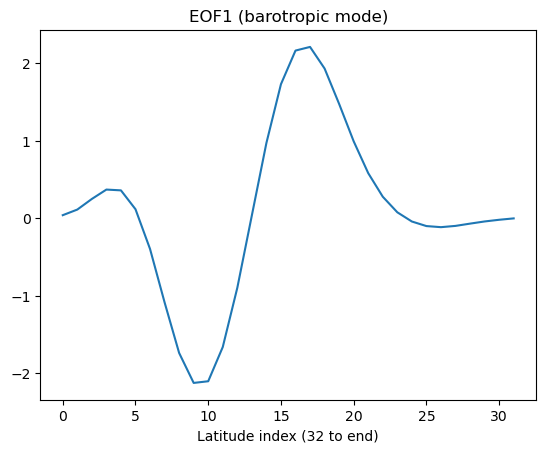

In [58]:
# --- Optional: Check EOF1 direction ---
plt.figure()
plt.plot(EOF1)
plt.title("EOF1 (barotropic mode)")
plt.xlabel("Latitude index (32 to end)")
# plt.grid(True)
plt.show()



In [59]:
# --- Compute EOF1 projection onto reshaped u field ---
u_reshape = np.mean(u[:, :, 32:, :], axis=3).reshape(ubar.shape[0], -1)  # shape: (time, lev*lat=20*32)
PC1_column = PC1.reshape(-1, 1)
EOF1_dot = u_reshape.T @ PC1_column / (PC1 @ PC1_column)  # shape: (lev*lat, 1)
EOF1_dot_reshape = EOF1_dot.reshape((u.shape[1], u.shape[2] - 32))  # shape: (20, 32)

In [147]:
def plot_contourf_near0_fixcolorbar_EOF(X, Y ,var_near0, axs, cbar_lim, shading_levels = 11, least_levels = 4, near0white = True, my_cmap = 'coolwarm'):
    from matplotlib.colors import ListedColormap
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    #####
    import matplotlib.colors as colors
    # a, antialiased = 0.6, True
#     a, antialiased = 0.7, True
    a, antialiased = 0.9, True
    # a, antialiased = 1, False
    
    my_cmap = plt.colormaps[my_cmap]  
    
    # create random data with cbar_lim
    rngdata = np.random.uniform(low=cbar_lim[0], high=cbar_lim[1], size=(len(Y),len(X)))
    
    # make sure the min and Max value are included
    rngdata[0,0] = cbar_lim[0]
    rngdata[-1,-1] = cbar_lim[1]

    # get contour levels with random data
    cs = axs.contourf(X, Y, rngdata, levels = 11, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels_rng = cs.levels.copy()
    plt.gca().clear()
    
    cs = axs.contourf(X, Y, var_near0, levels = auto_levels_rng, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels2 = cs.levels.copy()
    # cbar = add_colorbar(cs)#plt.colorbar()
    #plt.show()

    if ~((np.min(auto_levels2) >= 0) | (np.max(auto_levels2) <= 0)):
        plt.gca().clear()
        
        try:
            cbar.remove()
        except:
            pass
        
        # check levels of both ends
        # if either end has contour levels less than 'least_levels', create custom levels
        if ((len(np.where(auto_levels2 > 0)[0]) < least_levels) | (len(np.where(auto_levels2 < 0)[0]) < least_levels)):
            cs = plt.contourf(X,Y,var_near0, norm=TwoSlopeNorm(0), levels = np.linspace(auto_levels_rng.min(), auto_levels_rng.max(), 100))
            auto_levels1 = cs.levels.copy()
        #     plt.colorbar()
        #     plt.show()
            plt.gca().clear()
            if (len(np.where(auto_levels2 > 0)[0]) > len(np.where(auto_levels2 < 0)[0])):
                   custom_levels = np.concatenate((np.linspace(np.min(auto_levels1), 0, least_levels+1), 
                                    auto_levels2[auto_levels2 > 0]))

            else:
                   custom_levels = np.concatenate((auto_levels2[auto_levels2 < 0], 
                                               np.linspace(0,np.max(auto_levels1),least_levels+1)))

            #custom_levels = np.unique(custom_levels)
            custom_levels_bar = custom_levels
        else:

            custom_levels = auto_levels2
            custom_levels_bar = custom_levels

        # create white shading around 0
        if near0white:
            custom_lower = custom_levels[custom_levels < 0]
            dlevel_lower = custom_lower[1] - custom_lower[0]
            custom_lower_near0 = np.concatenate((custom_lower, [0 - dlevel_lower/5]))

            custom_upper = custom_levels[custom_levels > 0]
            dlevel_upper = custom_upper[1] - custom_upper[0]
            custom_upper_near0 = np.concatenate(([dlevel_upper/5 - 0] ,custom_upper))

            custom_levels_near0 = np.concatenate((custom_lower_near0, [0], custom_upper_near0))

            mycmap_lower_near0 = my_cmap(np.linspace(0, 0.5, len(custom_levels_near0[custom_levels_near0 < 0])))
            mycmap_upper_near0 = my_cmap(np.linspace(0.5, 1, len(custom_levels_near0[custom_levels_near0 >= 0])))[1:]
            all_colors = np.vstack((mycmap_lower_near0, mycmap_upper_near0))

            all_colors[np.where(custom_levels_near0 == 0)[0]] = [1, 1, 1, 1] # set to white
            all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [1, 1, 1, 1]
            
#             all_colors[np.where(custom_levels_near0 == 0)[0]] = [0.85, 0.85, 0.85, 1] # set to gray
#             all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [0.85, 0.85, 0.85, 1]

            #all_colors[:,0:3] *= a


            mycmap_near0 = colors.LinearSegmentedColormap.from_list('mycmap_near0', all_colors)

            custom_levels = custom_levels_near0
            mycmap = mycmap_near0
        else:
            mycmap = my_cmap


        norm = colors.BoundaryNorm(boundaries=custom_levels, ncolors=256)

        cs = axs.contourf(X, Y, var_near0, levels = custom_levels, cmap=mycmap, norm=norm, alpha = a, antialiased = antialiased)
        cbar = plt.colorbar(cs, spacing="proportional")#cbar = add_colorbar(cs, aspect=8, pad_fraction=0.8)#

#         cbar.set_ticks(custom_levels_bar)
#         ticklabs = cbar.ax.get_yticklabels()
#         cbar.ax.set_yticklabels(ticklabs, fontsize=14)

        # plt.title("c) EOF1", fontsize=14)
        # plt.xlabel("Latitude")
        ax.set_ylabel("Sigma")
        ax.invert_yaxis()
        # plt.ylim([1,0])
        # plt.xlim([0,70])


        
    #####
    return custom_levels, custom_levels_bar, cs

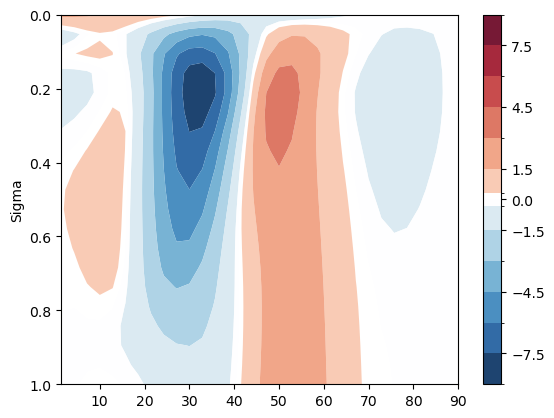

In [116]:
y = np.linspace(-90,90,64)

fig, ax = plt.subplots(1)
_,custom_levels_bar,cs=plot_contourf_near0_fixcolorbar_EOF(y[32:], np.linspace(0,1,20), EOF1_dot_reshape, ax, cbar_lim = [-9, 9],my_cmap = 'RdBu_r')


In [62]:
# --- Save to HDF5 ---
save_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_EOF1/PR{PR}_500_20000day_EOF1_2D.h5"
with h5py.File(save_path, "w") as f:
    f.create_dataset("EOF1_dot", data=EOF1_dot_reshape)
    f.attrs["description"] = "EOF1: zonal mean u projection onto PC1"
    f.attrs["dimensions"] = "(level, latitude>=32)"
    f.attrs["PR"] = PR
print(f"Saved EOF1 projection to {save_path}")

Saved EOF1 projection to /data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_EOF1/PR50_500_20000day_EOF1_2D.h5


# Calculate EP flux with Jucker 2020 method

In [7]:
PR = 0
u_file = f"/data92/PeterChang/Dycore_data/PR{PR}/u/PR{PR}_500_20000day_u_6hourly.h5"
v_file = f"/data92/PeterChang/Dycore_data/PR{PR}/v/PR{PR}_500_20000day_v_6hourly.h5"
p_file = f"/data92/PeterChang/Dycore_data/PR{PR}/p/PR{PR}_500_20000day_p_6hourly.h5"
t_file = f"/data92/PeterChang/Dycore_data/PR{PR}/t/PR{PR}_500_20000day_t_6hourly.h5"

In [21]:
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][:])

with h5py.File(v_file, "r") as ds:
    v = np.asarray(ds["v"][:])

with h5py.File(t_file, "r") as ds:
    t = np.asarray(ds["t"][:])

with h5py.File(p_file, "r") as ds:
    p = np.asarray(ds["p"][:])

In [69]:
# import EP flux def
import sys
sys.path.append('/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/')

# from Climate import ComputeEPfluxDiv
import importlib
import climate  

importlib.reload(climate)

<module 'climate' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/climate.py'>

In [ ]:
# Jucker EP flux pressure need to be hPa
lat = np.linspace(-90,90,64)
pres = p[:1000].mean(axis=(0,2,3))

In [75]:
ep1, ep2, _, dthdp, vptp = climate.ComputeEPfluxDiv(lat, pres/100, u[:], v[:], t[:])
# output: ep1 and ep2 (time, z, y)

In [ ]:
# Saving
# np.savez(f"epflux_PR{PR}.npz",
#          ep1=ep1,
#          ep2=ep2,
#          dthdp=dthdp,
#          lat=lat,
#          pres=pres,
#          vptp=vptp)
# print("Saving done")

In [71]:
# load
PR = 0 
data = np.load(f"epflux_PR{PR}.npz")
ep1 = data["ep1"]
ep2 = data["ep2"]
lat = data["lat"]
pres = data["pres"]
dthdp = data["dthdp"]
vptp = data["vptp"]


In [72]:
def set_size(w,h, ax=None):
	""" w, h: width, height in inches """
	if not ax: ax=plt.gca()
	l = ax.figure.subplotpars.left
	r = ax.figure.subplotpars.right
	t = ax.figure.subplotpars.top
	b = ax.figure.subplotpars.bottom
	figw = float(w)/(r-l)
	figh = float(h)/(t-b)
	ax.figure.set_size_inches(figw, figh)

Text(0.5, 1.0, 'EP flux PR0')

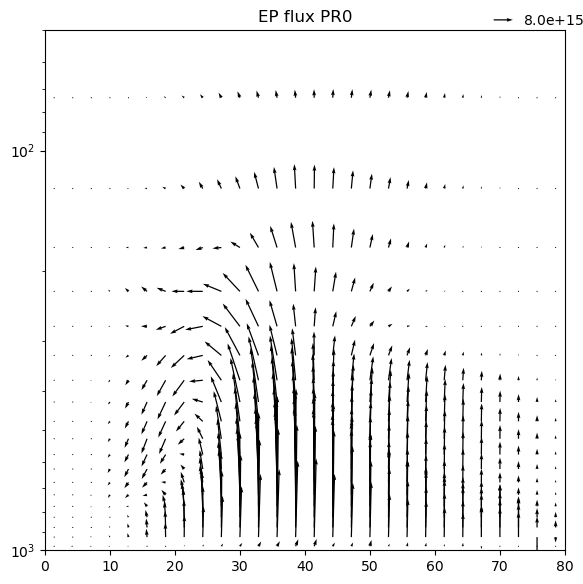

In [73]:
fig, ax = plt.subplots(1)
set_size(5.2, 5.2, ax)
Fphi, Fp = climate.PlotEPfluxArrows(lat, pres/100, np.nanmean(ep1[:], axis=0), np.nanmean(ep2[:], axis=0), fig, ax, scale=80E14, yscale="log")
plt.xlim([0,80])
plt.ylim([1000,50])
plt.title(f"EP flux PR{PR}")

# All exps

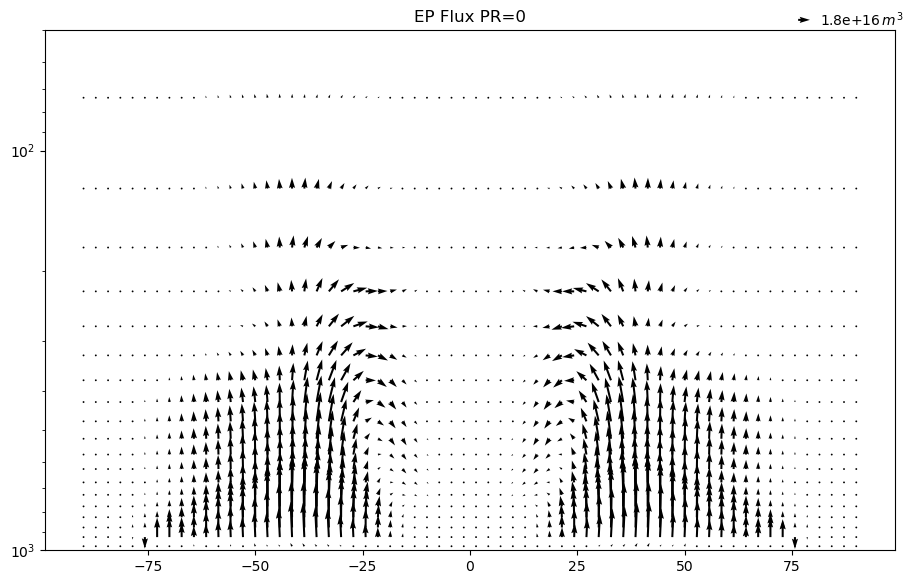

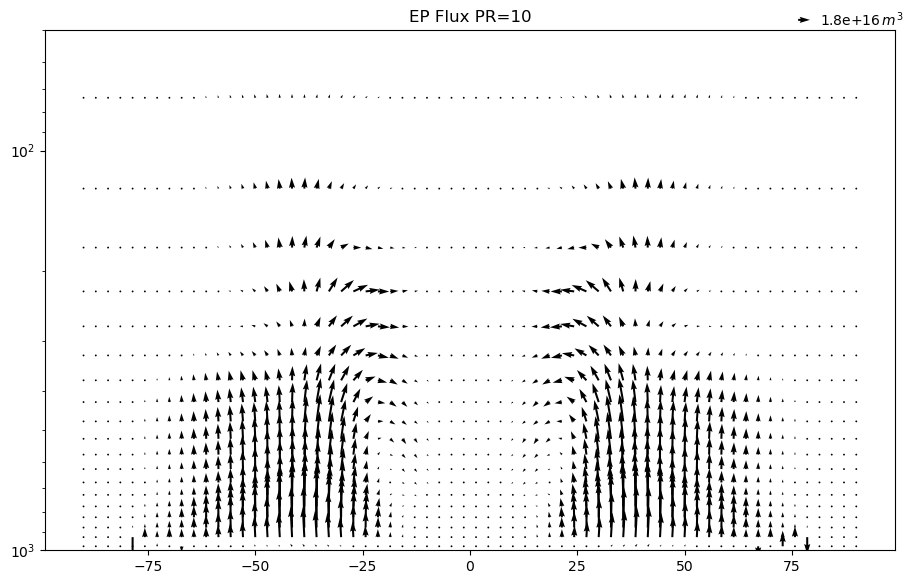

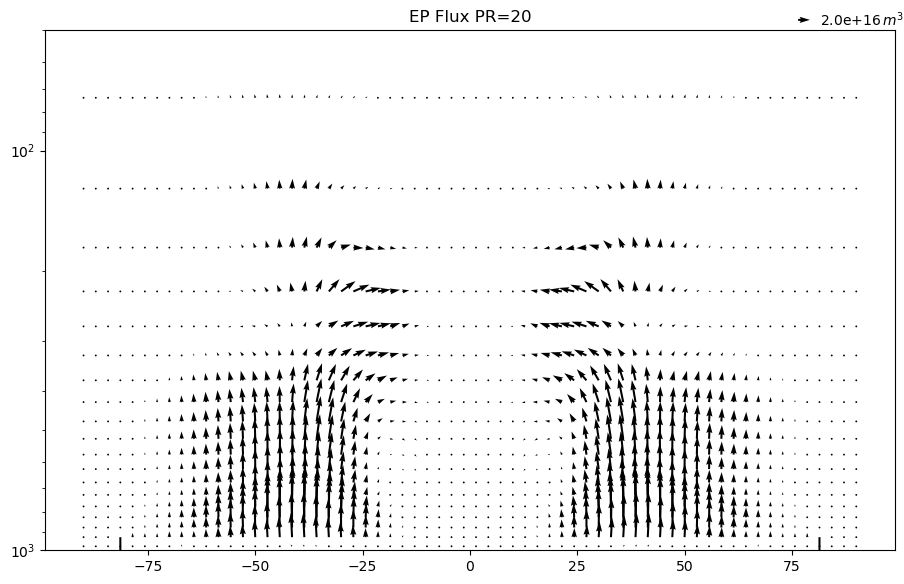

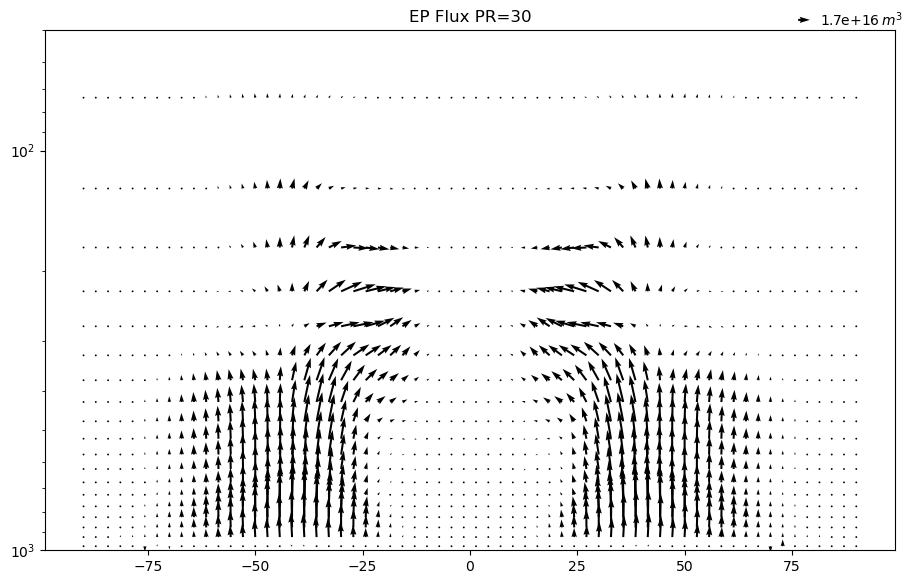

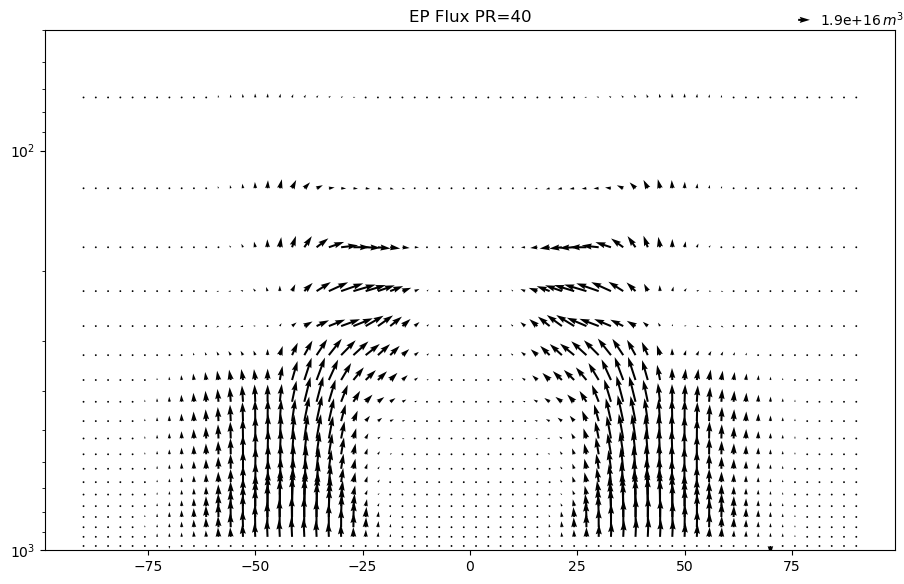

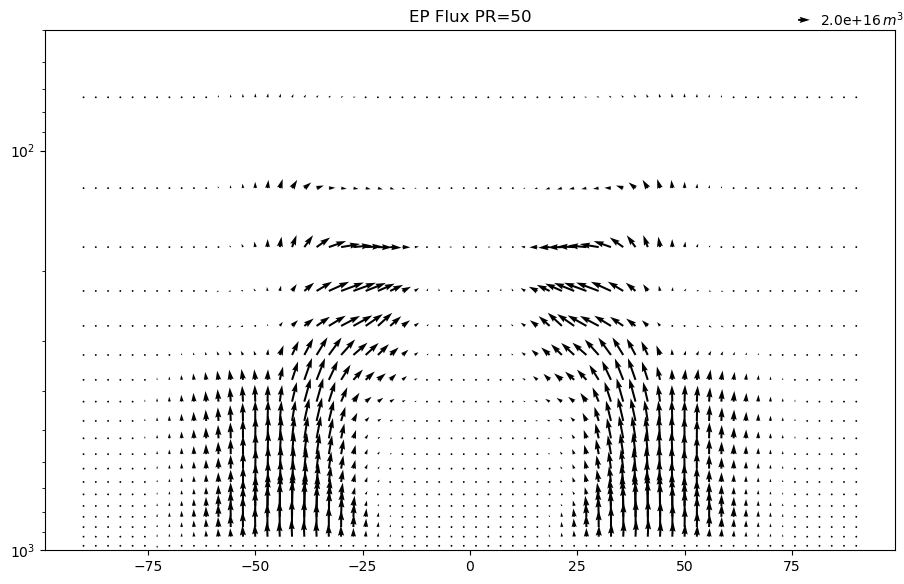

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def set_size(w, h, ax):
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w) / (r - l)
    figh = float(h) / (t - b)
    ax.figure.set_size_inches(figw, figh)

pr_values = [0, 10, 20, 30, 40, 50]
figs = []

for pr in pr_values:
    data = np.load(f"epflux_PR{pr}.npz")
    ep1 = data["ep1"]
    ep2 = data["ep2"]
    lat = data["lat"]
    pres = data["pres"]

    ep1_mean = ep1.mean(axis=0)
    ep2_mean = ep2.mean(axis=0)

    # --- Compute scaled vectors as in PlotEPfluxArrows ---
    a0 = 6376000.0
    g = 9.81
    cosphi = np.cos(np.deg2rad(lat))
    Fphi = 2 * np.pi / g * cosphi**2 * a0**2 * ep1_mean
    Fp   = 2 * np.pi / g * cosphi**2 * a0**3 * ep2_mean

    # Compute magnitude and 90th percentile
    magnitude = np.sqrt(Fphi**2 + Fp**2)
    scale_90 = np.percentile(magnitude, 30)

    # Plot
    fig, ax = plt.subplots(1)
    set_size(8.5, 5.2, ax)

    Fphi_out, Fp_out, = climate.PlotEPfluxArrows(
        lat, pres / 100, ep1_mean, ep2_mean, fig, ax,
        scale=scale_90, yscale="log"
    )

    ax.set_yscale("log")
    # ax.set_xlim([0, 80])
    ax.set_ylim([1000, 50])
    ax.set_title(f"EP Flux PR={pr}")

    figs.append(fig)
    plt.show()


# Composite EP flux with PC1 extreme time index 

In [182]:
def load_ep_flux_data(pr, save_dir):
    # with h5py.File(f"epflux_PR{pr}.npz", "r") as f:
    f = np.load(f"epflux_PR{pr}.npz", "r")
    print(f.keys())
    Fj = f["ep1"][:]  # (time, level, lat)
    Fk = f["ep2"][:]
    lat = f["lat"][:]
    pres = f["pres"][:]
    return Fj, Fk, lat, pres

def composite_mean(F, time_idx_array, lags):
    samples = []
    for lag in lags:
        time_idx_array_lag = time_idx_array + lag
        time_idx_array_lag = time_idx_array_lag[time_idx_array_lag<F.shape[0]]
        samples.append(F[time_idx_array_lag].mean(axis=0))
    print(len(samples))
    return np.mean(samples, axis=0)
    
def composite_alltime_mean(F):
    return np.mean(F, axis=0)
# Configuration
save_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/"

pr_list = [0,10,20,30,40,50]
lags_5_20 = np.arange(5*4, 25*4+1, 1) 
lags_30_60 = np.arange(90*4, 100*4+1, 1)

# Output
same_pr_ep_diff = {}

for PR in pr_list:
    print(f"\nLoading EP flux data for PR={PR}...")
    Fj, Fk, latitude, pres = load_ep_flux_data(PR, save_dir)
    print(Fj.shape)

    print(f"Loading time indices for PR={PR}...")
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_positive_1std_PR{PR}.h5") as f:
        print(f.keys())  # 看有哪些 key
        time_idx_pos = f["time_idx_pos"][:]
        print(time_idx_pos)

    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/New_PC1_time_idx/PC1_negative_1std_PR{PR}.h5") as f:
        print(f.keys())  # 看有哪些 key
        time_idx_neg = f["time_idx_neg"][:]

    
    ep1_ref = composite_alltime_mean(Fj)
    ep2_ref = composite_alltime_mean(Fk)
    
    print("--> Computing EP+ composite...")
    ep1_pos = composite_mean(Fj, time_idx_pos, lags_5_20)
    ep2_pos = composite_mean(Fk, time_idx_pos, lags_5_20)
    ep1_far_pos = composite_mean(Fj, time_idx_pos, lags_30_60)
    ep2_far_pos = composite_mean(Fk, time_idx_pos, lags_30_60)

    EP_plus   = ep1_pos - ep1_far_pos
    EP_plus_p = ep2_pos - ep2_far_pos

    print("--> Computing EP- composite...")
    ep1_neg = composite_mean(Fj, time_idx_neg, lags_5_20)
    ep2_neg = composite_mean(Fk, time_idx_neg, lags_5_20)
    ep1_far_neg = composite_mean(Fj, time_idx_neg, lags_30_60)
    ep2_far_neg = composite_mean(Fk, time_idx_neg, lags_30_60)

    EP_minus   = ep1_neg - ep1_far_neg
    EP_minus_p = ep2_neg - ep2_far_neg

    diff_phi = EP_plus   - EP_minus
    diff_p   = EP_plus_p - EP_minus_p

    same_pr_ep_diff[PR] = (diff_phi, diff_p)

    # Create xarray Dataset and save
    level = pres # np.linspace(1000, 100000, diff_phi.shape[0])
    lat = latitude # np.linspace(-90, 90, diff_phi.shape[1])
    ds = xr.Dataset({
        f"EP_phi_diff_PR{PR}": (["level", "lat"], diff_phi),
        f"EP_p_diff_PR{PR}":   (["level", "lat"], diff_p),
        f"ep1_pos":   (["level", "lat"], ep1_pos),
        f"ep2_pos":   (["level", "lat"], ep2_pos),

        f"ep1_neg":   (["level", "lat"], ep1_neg),
        f"ep2_neg":   (["level", "lat"], ep2_neg),
        
        f"ep1_ref":   (["level", "lat"], ep1_ref),
        f"ep2_ref":   (["level", "lat"], ep2_ref),
        
        
    }, coords={"level": level, "lat": lat})

    save_path = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/same_pr_ep_diff_PR{PR}.nc"
    print(f"Saving composite diff to {save_path}...")
    ds.to_netcdf(save_path)
    print("✓ Save complete.")



Loading EP flux data for PR=0...
KeysView(NpzFile 'epflux_PR0.npz' with keys: ep1, ep2, dthdp, lat, pres...)
(78000, 20, 64)
Loading time indices for PR=0...
<KeysViewHDF5 ['time_idx_pos']>
[[  391   392   393 ... 77017 77018 77019]]
<KeysViewHDF5 ['time_idx_neg']>
--> Computing EP+ composite...
81
81
41
41
--> Computing EP- composite...
81
81
41
41
Saving composite diff to /data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/same_pr_ep_diff_PR0.nc...
✓ Save complete.

Loading EP flux data for PR=10...
KeysView(NpzFile 'epflux_PR10.npz' with keys: ep1, ep2, dthdp, lat, pres...)
(78000, 20, 64)
Loading time indices for PR=10...
<KeysViewHDF5 ['time_idx_pos']>
[[  780   781   782 ... 77843 77844 77845]]
<KeysViewHDF5 ['time_idx_neg']>
--> Computing EP+ composite...
81
81
41
41
--> Computing EP- composite...
81
81
41
41
Saving composite diff to /data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/same_pr_ep_diff_PR10.nc...
✓ Save complete.

Loading EP flux data for PR=20...
Key

In [213]:
with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/PR10_vs_PR0_EP_diff_stat_test.nc", "r") as f:        
    print(f.keys())
    statis_test_PR10 = f["rand_diff_phi_PR10_vs_PR0"][:]
    diff_phi_PR10 = f["real_diff_phi_PR10_vs_PR0"][:]
    

<KeysViewHDF5 ['lat', 'level', 'rand_diff_p_PR10_vs_PR0', 'rand_diff_phi_PR10_vs_PR0', 'real_diff_p_PR10_vs_PR0', 'real_diff_phi_PR10_vs_PR0', 'sample']>


33 1


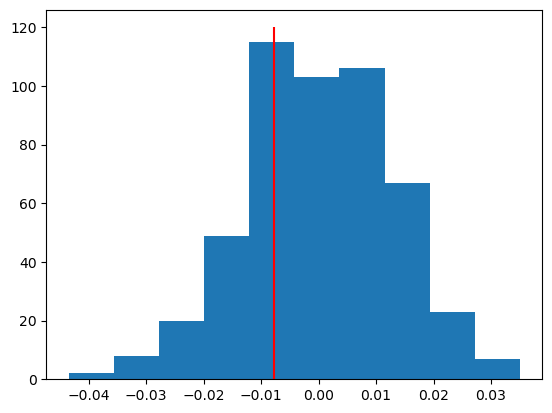

In [239]:
import random
random_y = random.randint(0,63)
random_z = random.randint(0,19) 
print(random_y, random_z)
plt.figure()
plt.hist(statis_test_PR10[:,random_z,random_y])
plt.vlines(x=diff_phi_PR10[random_z,random_y], ymin=0, ymax=120, color="Red")

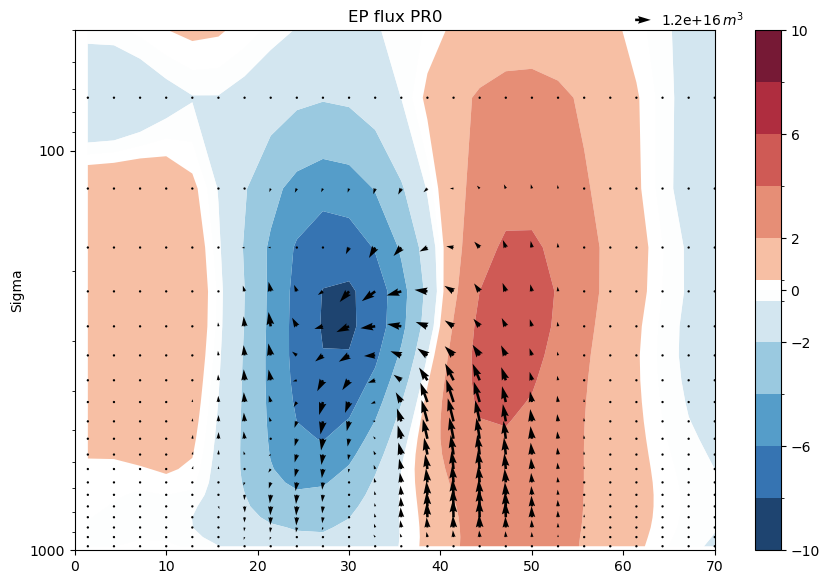

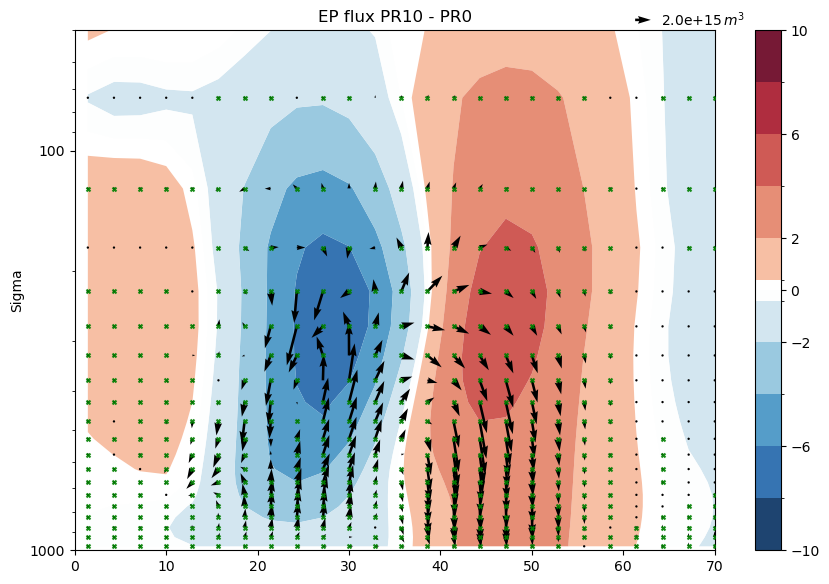

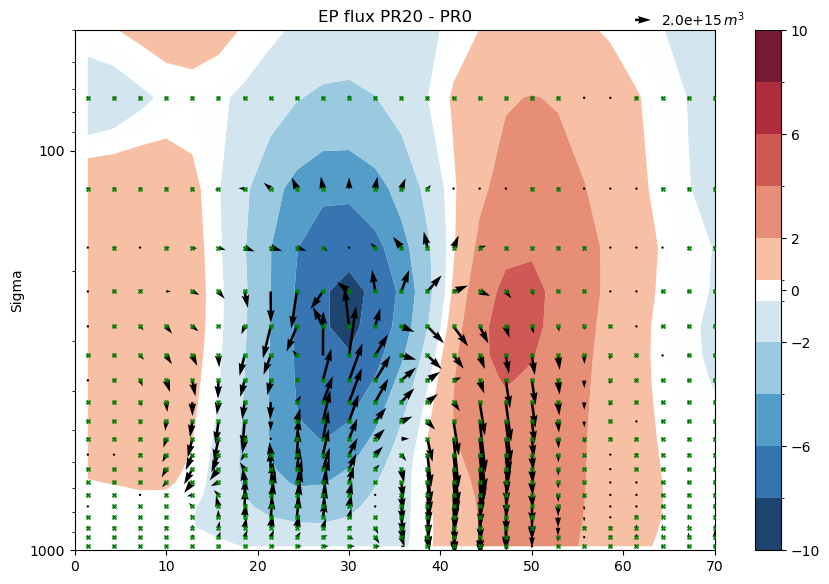

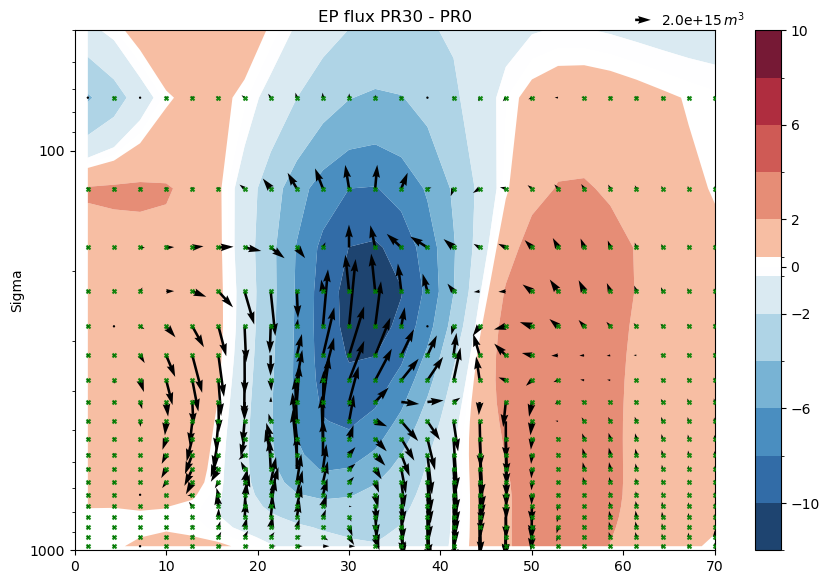

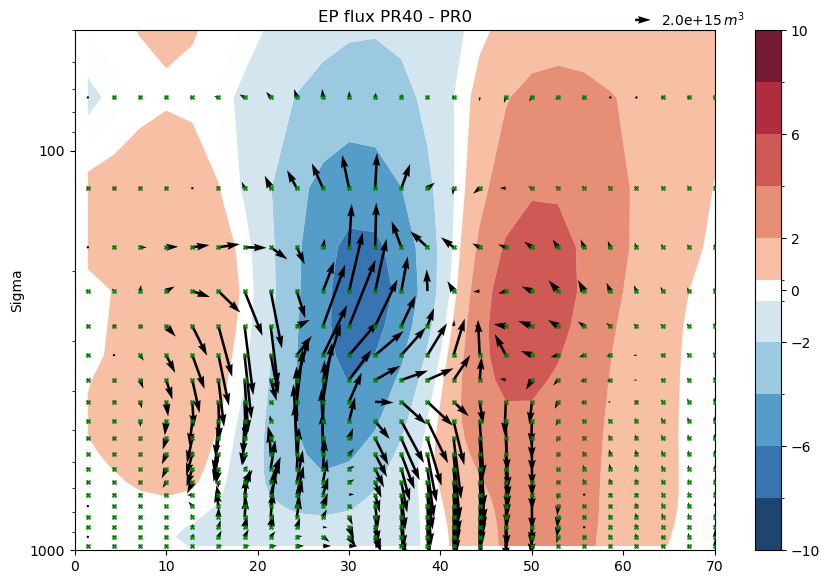

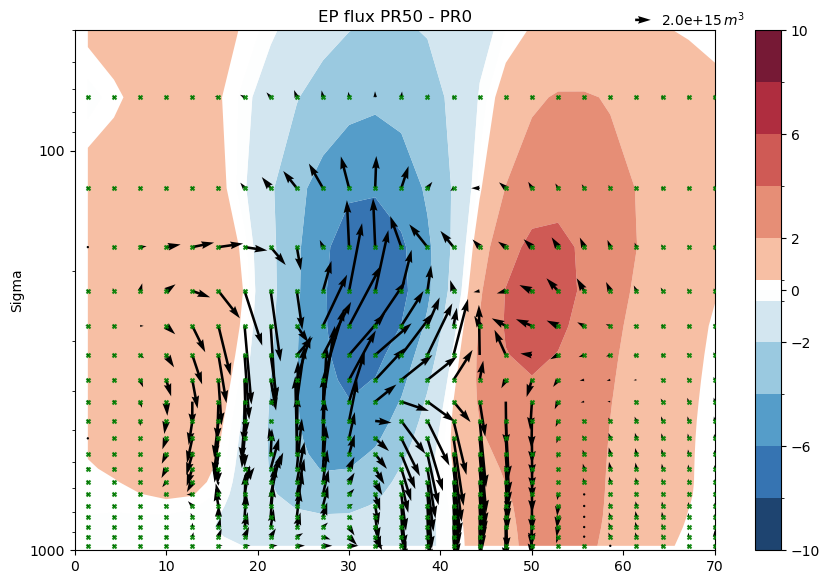

In [261]:
# import sys
import numpy as np
import h5py
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sys.path.append('/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/')
import importlib
import climate
importlib.reload(climate)

def set_size(w, h, ax=None):
    """Set figure size in inches"""
    if ax is None:
        ax = plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w) / (r - l)
    figh = float(h) / (t - b)
    ax.figure.set_size_inches(figw, figh)

for PR in range(0, 60, 10):
    # === Load EP flux and EOF1 ===
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/same_pr_ep_diff_PR{PR}.nc", "r") as f:
        diff_phi_new = f[f"EP_phi_diff_PR{PR}"][:]
        diff_p_new = f[f"EP_p_diff_PR{PR}"][:]
        ep1_pos = f["ep1_pos"][:]
        ep2_pos = f["ep2_pos"][:]
        ep1_neg = f["ep1_neg"][:]
        ep2_neg = f["ep2_neg"][:]
        ep1_ref = f["ep1_ref"][:]
        ep2_ref = f["ep2_ref"][:]
        lat = f["lat"][:]
        level = f["level"][:]

    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_EOF1/PR{PR}_500_20000day_EOF1_2D.h5", "r") as f:
        EOF1 = f["EOF1_dot"][:]

    ep1_pos_neg = ep1_pos - ep1_neg
    ep2_pos_neg = ep2_pos - ep2_neg

    if PR == 0:
        EOF1_PR0 = EOF1
        ep1_pos_neg_PR0 = ep1_pos_neg
        ep2_pos_neg_PR0 = ep2_pos_neg

        fig, ax = plt.subplots(1)
        set_size(8., 5.2, ax)
        _, _, cs = plot_contourf_near0_fixcolorbar_EOF(lat[32:], level / 100, EOF1_PR0, ax, cbar_lim=[-9.5, 9.5], my_cmap='RdBu_r')
        Fphi, Fp = climate.PlotEPfluxArrows(lat, level / 100, ep1_pos_neg_PR0, ep2_pos_neg_PR0,
                                            fig, ax, scale=120E14, yscale="log",
                                            quiv_args={'angles': 'uv', 'scale_units': 'inches', 'pivot': 'tail', 'width': 4e-3})
        plt.xlim([0, 70])
        plt.ylim([1000, 50])
        plt.title(f"EP flux PR{PR}")
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

    else:
        fig, ax = plt.subplots(1)
        set_size(8., 5.2, ax)
        _, _, cs = plot_contourf_near0_fixcolorbar_EOF(lat[32:], level / 100, EOF1, ax,
                                                               cbar_lim=[-11, 10] if PR == 30 else [-10, 10],
                                                               my_cmap='RdBu_r')
        Fphi, Fp = climate.PlotEPfluxArrows(lat, level / 100,
                                            ep1_pos_neg - ep1_pos_neg_PR0,
                                            ep2_pos_neg - ep2_pos_neg_PR0,
                                            fig, ax, scale=20E14, yscale="log",
                                            quiv_args={'angles': 'uv', 'scale_units': 'inches', 'pivot': 'tail', 'width': 4e-3})

        # === Add Statistical Significance (phi AND p) ===
        save_stat_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/"
        save_path_samples = f"{save_stat_dir}/EPflux/PR{PR}_vs_PR0_EP_diff_stat_test.nc"
        with xr.open_dataset(save_path_samples) as ds_stat:
            rand_phi = ds_stat[f"rand_diff_phi_PR{PR}_vs_PR0"].values  # (sample, lev, lat)
            rand_p = ds_stat[f"rand_diff_p_PR{PR}_vs_PR0"].values      # (sample, lev, lat)

        # Compute percentile thresholds
        lower_phi = np.percentile(rand_phi, 0.1, axis=0)
        upper_phi = np.percentile(rand_phi, 99.9, axis=0)
        lower_p   = np.percentile(rand_p, 0.1, axis=0)
        upper_p   = np.percentile(rand_p, 99.9, axis=0)

        # Compute actual differences
        real_diff_phi = ep1_pos_neg - ep1_pos_neg_PR0
        real_diff_p   = ep2_pos_neg - ep2_pos_neg_PR0

        # Combine significance masks
        sig_phi = (real_diff_phi < lower_phi) | (real_diff_phi > upper_phi)
        sig_p   = (real_diff_p   < lower_p)   | (real_diff_p   > upper_p)
        sig = sig_phi & sig_p  # AND condition

        # Plot only where both phi and p are significant
        sig_lev_idx, sig_lat_idx = np.where(sig[:, 32:])
        sig_lat = lat[32:][sig_lat_idx]
        sig_lev = level[sig_lev_idx] / 100
        ax.scatter(sig_lat, sig_lev, s=8, color='g', marker='x', alpha=0.9, zorder=5)

        plt.xlim([0, 70])
        plt.ylim([1000, 50])
        plt.title(f"EP flux PR{PR} - PR0")
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.show()


# plot EMF and Annular mode

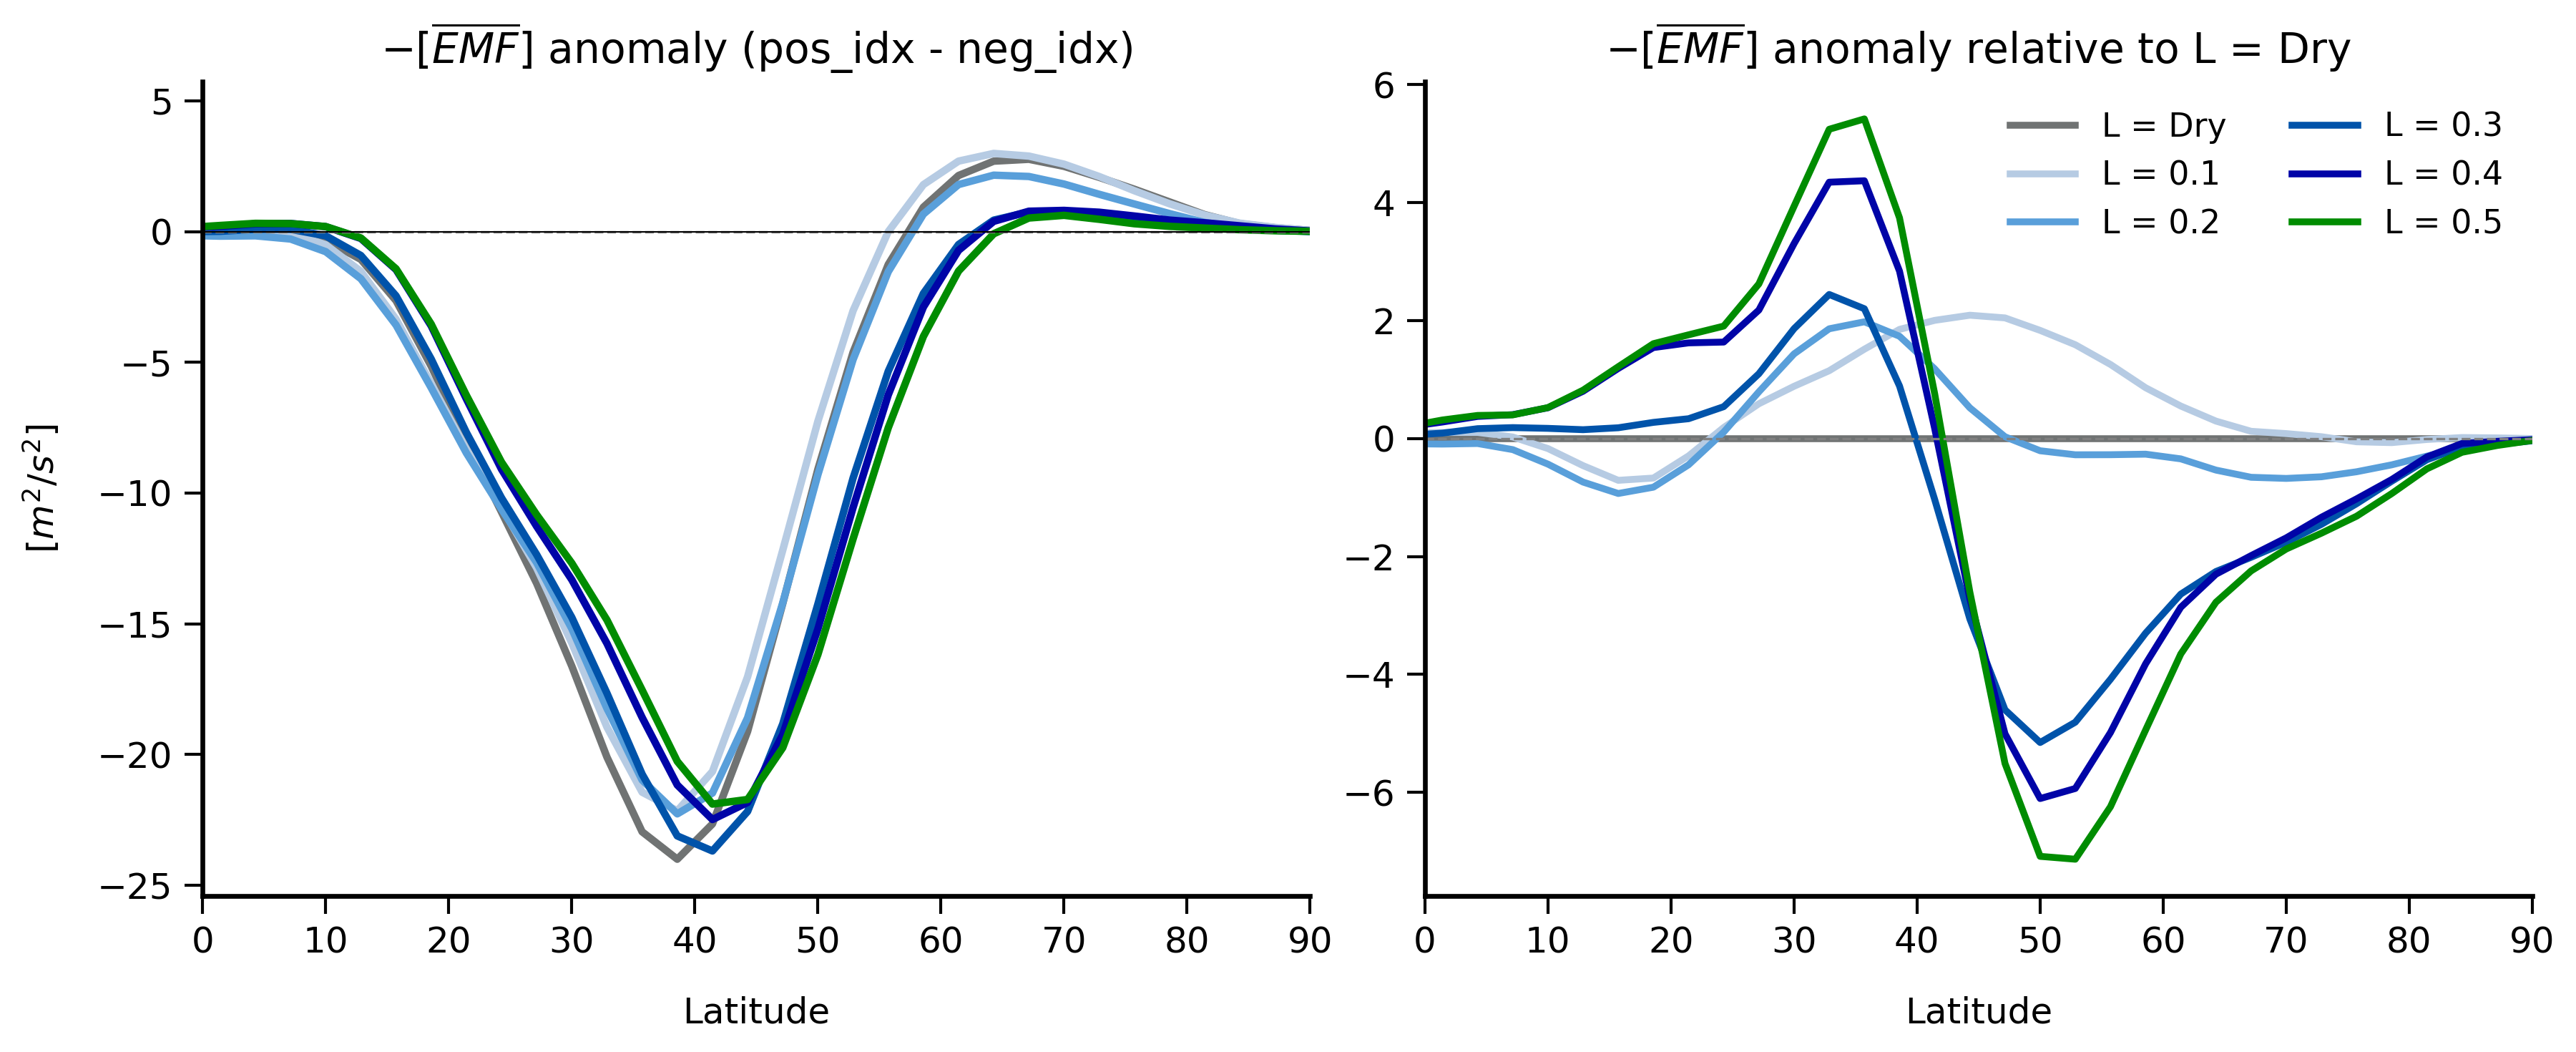

In [358]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 1.6

idx_dir = "/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/"
pr_list = [0, 10, 20, 30, 40, 50]
emf_diff_all = {}

# 自訂顏色
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218], 
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0


for PR in pr_list:
    with h5py.File(f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/EMF_add_time_dim/EMF_climatology_add_time_dim.h5", "r") as f:
        EMF = -f["EMF"][:]  # shape: (time, lat)

    with h5py.File(f"{idx_dir}/PC1_positive_1std_PR{PR}.h5") as f:
        idx_pos = f["time_idx_pos"][:][0]
    with h5py.File(f"{idx_dir}/PC1_negative_1std_PR{PR}.h5") as f:
        idx_neg = f["time_idx_neg"][:][0]

    EMF_pos = EMF[idx_pos].mean(axis=0)
    EMF_neg = EMF[idx_neg].mean(axis=0)
    emf_diff = EMF_pos - EMF_neg  # shape: (lat,)
    emf_diff_all[PR] = emf_diff

lat = np.linspace(-90, 90, len(emf_diff))

# === Create horizontal figure with subplots ===
fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
ax1, ax2 = ax

# === Left Plot: EMF (pos - neg) ===
for i, PR in enumerate(pr_list):
    label = f"L = {PR * 0.01:.2f}"
    ax1.plot(lat, emf_diff_all[PR], label=label, lw=2.5, color=colors[i])

ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.set_xlabel("Latitude", fontsize=12 , labelpad=12)
ax1.set_ylabel(r"$[m^2/s^2]$", fontsize=12 , labelpad=12)
ax1.set_title(r"$-[\overline{EMF}]$ anomaly (pos_idx - neg_idx)", fontsize=14)
# ax1.legend(fontsize=10, frameon=True)
# ax1.grid(True)
ax1.set_xlim([0, 90])
# ax1.hlines(y=0, xmin=10, xmax=90, color="k")
ax1.axhline(y=0, color="black", lw=0.5)
ax1.vlines(0, ymin=-0.1,ymax=1, colors="black", linewidth=0.7)
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.tick_params(axis='x', labelsize=12, pad=4)
ax1.tick_params(axis='y', labelsize=12, pad=4)
ax1.tick_params(direction='out', length=6, width=1)

# === Right Plot: PRi - PR0 ===
for i, PR in enumerate(pr_list[:]):  # Skip PR=0
    label = f"L = {PR * 0.01:.1f}"
    if PR == 0:
        ax2.plot(lat, emf_diff_all[PR] - emf_diff_all[0], label="L = Dry", lw=2.3, color=colors[i])
    else:
        ax2.plot(lat, emf_diff_all[PR] - emf_diff_all[0], label=label, lw=2.3, color=colors[i])

ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_xlabel("Latitude", fontsize=12 , labelpad=12)
ax2.set_title(r"$-[\overline{EMF}]$ anomaly relative to L = Dry", fontsize=14)
# ax2.legend(fontsize=10, frameon=True, )
ax2.legend(loc="best", prop={'size': 11}, frameon=False, ncols=2)
# ax2.grid(True)
ax2.set_xlim([0, 90])
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
# ax2.tick_params(axis='x', labelsize=10)
# ax2.tick_params(axis='y', labelsize=10)
ax2.tick_params(axis='x', labelsize=12, pad=4)
ax2.tick_params(axis='y', labelsize=12, pad=4)
ax2.tick_params(direction='out', length=6, width=1)

plt.tight_layout()
plt.show()
